## Recon contract for `outputs/250_recon` (my local folder sturcture)
```markdown

### 1. Per-patient native brain plots (PAT space)

**Patient root**

`\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators\PAT_XXXX\`

**Required**

- Cortex surfaces (for plotting the brain)
  - `surf/lh.pial`
  - `surf/rh.pial`

- MRI for coordinate transforms
  - `mri/brainmask.mgz`

- Electrode positions (native reconstruction)
  - `elec_recon/PAT_XXXX.LEPTOVOX`
  - `elec_recon/PAT_XXXX.electrodeNames`

**Optional (native atlas / tissue labels)**

- `mri/aparc+aseg.mgz`  
- `mri/aparc.a2009s+aseg.mgz`  
- `mri/wmparc.mgz`  
- `mri/transforms/talairach.xfm`


### 2. Combined electrode coverage on fsaverage (group plot)

**Per-patient BIDS electrodes (already in fsaverage space)**

`\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators\PAT_XXXX\BIDS\ieeg\`

- `sub-XXXX_electrodes.tsv`
- `sub-XXXX_coordsystem.json`

**fsaverage anatomy**

`\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators\fsaverage\`

- `surf/lh.pial`
- `surf/rh.pial`

### 3. Parcellation-highlighted fsaverage plots (with or without electrodes)

**fsaverage surfaces + parcellations**

`\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators\fsaverage\`

- Surfaces  
  - `surf/lh.pial`  
  - `surf/rh.pial`

- Parcellation annotation files  
  - `label/lh.aparc.annot`  
  - `label/rh.aparc.annot`  
  - `label/lh.aparc.a2009s.annot`  
  - `label/rh.aparc.a2009s.annot`  
  - `label/lh.aparc.DKTatlas.annot`  
  - `label/rh.aparc.DKTatlas.annot`

**Optional overlay**

- Same BIDS electrodes as in section 2:
  - `PAT_XXXX/BIDS/ieeg/sub-XXXX_electrodes.tsv`
```


## 250_recon/PAT_XXXX -- Generate and save the trsRAS contact coordonates in my drive using LEPTOVOX. 
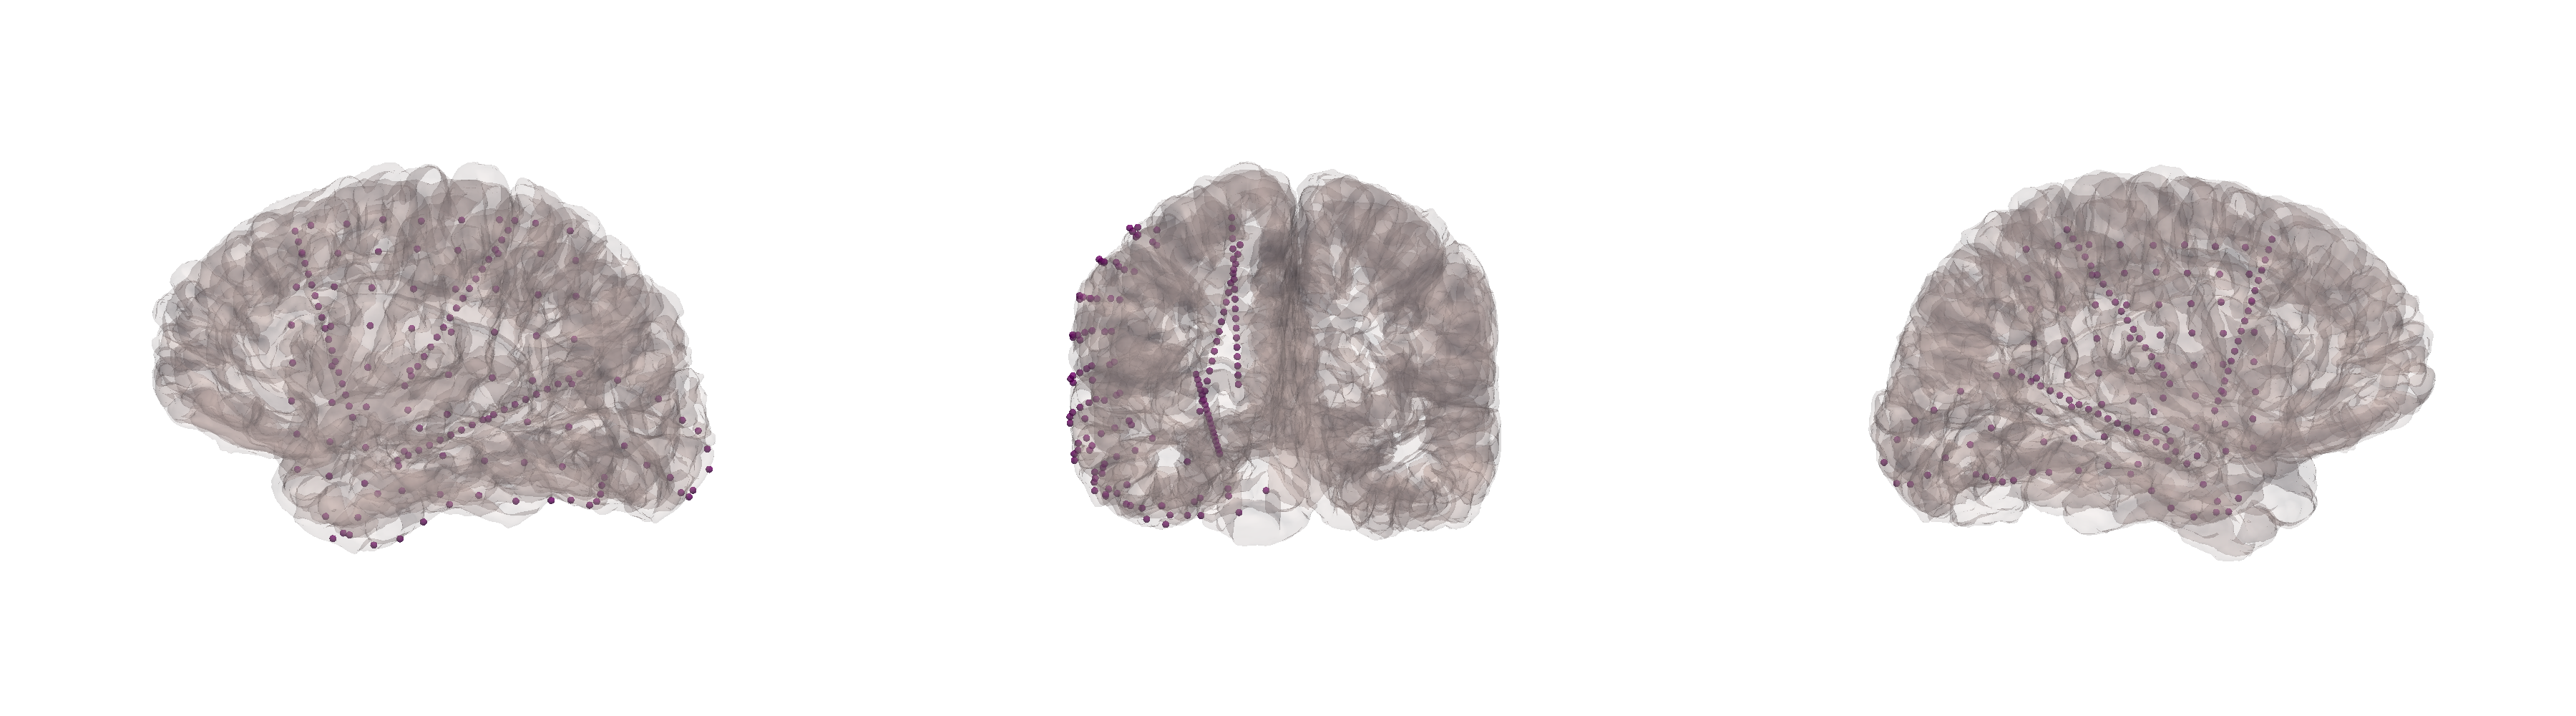

In [3]:
# ============================================================
# ONE CELL: Fixed LEPTOVOX convention
#   perm  = (0,1,2)  (XYZ as-is)
#   flips = (0,0,1)  (flip k only: k' = (dim_z-1)-k)
#
# Batch over all PAT_* in SHARED_ROOT and write:
#   OUT_ROOT/PAT_XXXX/glassbrain/coords/PAT_XXXX_contacts_tkrRAS.csv
#   OUT_ROOT/PAT_XXXX/glassbrain/png/PAT_XXXX_mosaic_LEPTOVOX.png
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import pyvista as pv
import imageio.v3 as iio
from nibabel.freesurfer.io import read_geometry
from scipy.spatial import cKDTree


# -------------------------
# CONFIG
# -------------------------
SHARED_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators")  # change to where your PAT_XXX folders are
OUT_ROOT    = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon") # Change to where you want the data to be saved, in drive format

# Fixed convention you determined:
PERM  = (0, 1, 2)            # use columns as-is
FLIPS = (False, False, True) # flip k only

# render params
VIEWS = ("left", "frontal", "right")
WINDOW_SIZE = (1200, 1000)
TRANSPARENT_BG = True
BRAIN_COLOR = "#ead6db"
BRAIN_OPACITY = 0.25
POINT_COLOR = "purple"
POINT_SIZE = 10
POINT_OPACITY = 0.9

OVERWRITE_CSV = True
OVERWRITE_PNG = True

# Helpers: 
#---------
def read_electrode_lines_drop2(path: Path) -> list[str]:
    lines = [ln.strip() for ln in path.read_text(encoding="utf-8", errors="ignore").splitlines() if ln.strip()]
    if len(lines) < 3:
        raise ValueError(f"electrodeNames too short: {path}")
    return lines[2:]  # drop timestamp + header

def parse_name_and_hemi(lines: list[str]):
    """
    lines look like: 'FPG1 D L'
    returns:
      name_raw (full line), name (first token), hemi_expected (L/R/None)
    """
    names_raw, names_clean, hemi = [], [], []
    for ln in lines:
        parts = ln.split()
        nm = parts[0] if len(parts) else ln
        h = None
        if len(parts):
            last = parts[-1].upper()
            if last in ("L", "R"):
                h = last
        names_raw.append(ln)
        names_clean.append(nm)
        hemi.append(h)
    return np.array(names_raw, dtype=object), np.array(names_clean, dtype=object), np.array(hemi, dtype=object)

def read_leptovox_xyz(path: Path) -> np.ndarray:
    rows = []
    for ln in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        t = ln.strip()
        if not t or t.startswith("#"):
            continue
        parts = t.replace(",", " ").split()
        if len(parts) < 3:
            continue
        try:
            rows.append((float(parts[0]), float(parts[1]), float(parts[2])))
        except ValueError:
            continue
    if not rows:
        raise ValueError(f"No numeric rows found in {path}")
    return np.asarray(rows, dtype=float)

def pick_mgz(subj_dir: Path) -> Path:
    for cand in ["brainmask.mgz", "T1.mgz", "orig.mgz"]:
        p = subj_dir / "mri" / cand
        if p.is_file():
            return p
    raise FileNotFoundError(f"Missing brainmask/T1/orig in {subj_dir/'mri'}")



# Geometry helpers
# ----------------
def voxel_to_tkr(points_ijk: np.ndarray, vox2ras_tkr: np.ndarray) -> np.ndarray:
    n = points_ijk.shape[0]
    ijk_h = np.c_[points_ijk, np.ones(n)]
    tkr_h = (vox2ras_tkr @ ijk_h.T).T
    return tkr_h[:, :3]

def apply_voxel_flips(ijk: np.ndarray, vol_shape, flips=(False, False, True)) -> np.ndarray:
    dims = np.array(vol_shape, dtype=float)
    out = ijk.copy()
    for ax, do_flip in enumerate(flips):
        if do_flip:
            out[:, ax] = (dims[ax] - 1.0) - out[:, ax]
    return out

def nearest_pial_metrics(points_tkr: np.ndarray, lh_v: np.ndarray, rh_v: np.ndarray):
    kdl = cKDTree(lh_v)
    kdr = cKDTree(rh_v)
    dl, _ = kdl.query(points_tkr, k=1, workers=-1)
    dr, _ = kdr.query(points_tkr, k=1, workers=-1)
    is_left = dl <= dr
    dist = np.minimum(dl, dr)
    return dist, is_left



# Rendering helpers
# -------------------------
def make_mesh(v, f):
    return pv.PolyData(v, np.c_[np.full(len(f), 3), f].astype(np.int64))

def set_view(pl, view):
    view = view.lower()
    if view == "left":
        pl.view_yz(negative=True)
    elif view == "frontal":
        pl.view_xz(negative=False)
    elif view == "right":
        pl.view_yz(negative=False)
    else:
        raise ValueError(view)
    pl.camera.zoom(1.15)

def render_view(lh_mesh, rh_mesh, points_tkr, view):
    pl = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
    pl.set_background("white")
    pl.add_mesh(lh_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY, smooth_shading=True)
    pl.add_mesh(rh_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY, smooth_shading=True)
    pl.add_points(points_tkr, color=POINT_COLOR, render_points_as_spheres=True,
                  point_size=POINT_SIZE, opacity=POINT_OPACITY)
    set_view(pl, view)
    img = pl.screenshot(transparent_background=TRANSPARENT_BG, return_img=True)
    pl.close()
    return img

def stitch_horiz(imgs):
    H = min(im.shape[0] for im in imgs)
    imgs = [im[:H] for im in imgs]
    return np.concatenate(imgs, axis=1)


# Per patient
# -------------------------
def export_and_mosaic_patient(pid: str):
    pid = str(pid)
    subj_dir = SHARED_ROOT / pid

    names_path = subj_dir / "elec_recon" / f"{pid}.electrodeNames"
    vox_path   = subj_dir / "elec_recon" / f"{pid}.LEPTOVOX"
    if not names_path.is_file():
        raise FileNotFoundError(f"{pid}: missing {names_path}")
    if not vox_path.is_file():
        raise FileNotFoundError(f"{pid}: missing {vox_path}")

    mgz = pick_mgz(subj_dir)
    img = nib.load(str(mgz))
    vox2ras_tkr = img.header.get_vox2ras_tkr()
    vol_shape = img.shape[:3]

    # surfaces
    lh_v, lh_f = read_geometry(str(subj_dir / "surf" / "lh.pial"))
    rh_v, rh_f = read_geometry(str(subj_dir / "surf" / "rh.pial"))
    lh_mesh = make_mesh(lh_v, lh_f)
    rh_mesh = make_mesh(rh_v, rh_f)

    # names
    lines = read_electrode_lines_drop2(names_path)
    name_raw, name_clean, hemi_expected = parse_name_and_hemi(lines)

    # leptovox coords
    pts = read_leptovox_xyz(vox_path)
    if pts.shape[0] != len(name_raw):
        raise RuntimeError(f"{pid}: LEPTOVOX rows ({pts.shape[0]}) != electrodeNames contacts ({len(name_raw)})")

    # 0/1-based detection
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    dims = np.array(vol_shape, dtype=float)

    looks_one_based  = (mins >= 1).all() and (maxs <= dims).all()
    looks_zero_based = (mins >= 0).all() and (maxs <  dims).all()

    pts_ijk = pts.copy()
    index_mode = "0-based (assumed)"
    if looks_one_based and not looks_zero_based:
        pts_ijk -= 1.0
        index_mode = "1-based->0-based"

    # apply fixed perm + flips
    pts_ijk = pts_ijk[:, PERM]  # (0,1,2) = no-op, kept for explicitness
    pts_ijk = apply_voxel_flips(pts_ijk, vol_shape, FLIPS)  # flip k only

    # voxel -> tkrRAS
    pts_tkr = voxel_to_tkr(pts_ijk, vox2ras_tkr)

    # dist + hemi prediction
    dist_mm, pred_is_left = nearest_pial_metrics(pts_tkr, lh_v, rh_v)

    # outputs
    out_coords = OUT_ROOT / pid / "glassbrain" / "coords"
    out_pngdir = OUT_ROOT / pid / "glassbrain" / "png"
    out_coords.mkdir(parents=True, exist_ok=True)
    out_pngdir.mkdir(parents=True, exist_ok=True)

    out_csv = out_coords / f"{pid}_contacts_tkrRAS.csv"
    out_png = out_pngdir / f"{pid}_mosaic_LEPTOVOX.png"

    # CSV
    if OVERWRITE_CSV or (not out_csv.is_file()):
        df_out = pd.DataFrame({
            "name_raw": name_raw,
            "name": name_clean,
            "hemi_expected": hemi_expected,
            "x": pts_tkr[:,0], "y": pts_tkr[:,1], "z": pts_tkr[:,2],
            "pred_isLeft": pred_is_left.astype(int),
            "dist_to_pial_mm": np.round(dist_mm, 2),
            "source_space": "tkrRAS",
            "source_provenance": f"LEPTOVOX; {index_mode}; perm={PERM}; flips={tuple(int(b) for b in FLIPS)} (flip k only)",
            "leptovox_file": str(vox_path),
            "mgz_used": str(mgz),
        })
        df_out.to_csv(out_csv, index=False)

    # Mosaic
    if OVERWRITE_PNG or (not out_png.is_file()):
        imgs = [render_view(lh_mesh, rh_mesh, pts_tkr, v) for v in VIEWS]
        mosaic = stitch_horiz(imgs)
        iio.imwrite(out_png, mosaic)

    # quick stats
    med_dist = float(np.median(dist_mm))
    pct_left = float(np.mean(pred_is_left) * 100.0)

    return {
        "pid": pid,
        "status": "OK",
        "n_contacts": int(len(name_raw)),
        "median_dist_to_pial_mm": med_dist,
        "pct_pred_left": pct_left,
        "index_mode": index_mode,
        "csv": str(out_csv),
        "png": str(out_png),
    }


# -------------------------
# Batch run all PAT_* (Careful, this runs ALL patients in the shared folder. make another patient_ids variable with list of patient names ["PAT_3066","" ...]
# -------------------------
patient_ids = sorted([p.name for p in SHARED_ROOT.iterdir() if p.is_dir() and p.name.startswith("PAT_")])

rows = []
for pid in patient_ids:
    try:
        rows.append(export_and_mosaic_patient(pid))
    except Exception as e:
        rows.append({"pid": pid, "status": "ERROR", "error": str(e)})

df_status = pd.DataFrame(rows)
df_status


,pid,status,n_contacts,median_dist_to_pial_mm,pct_pred_left,index_mode,csv,png
0,PAT_1145,OK,142,4.131500,88.028169,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
1,PAT_2856,OK,176,3.078871,94.318182,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
2,PAT_2868,OK,63,3.539747,100.000000,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
3,PAT_2893,OK,173,3.338248,94.219653,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
4,PAT_3066,OK,200,3.530114,65.500000,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
5,PAT_3301,OK,202,4.040088,52.970297,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
6,PAT_3390,OK,118,3.740455,100.000000,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
7,PAT_3415,OK,148,1.312528,100.000000,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
8,PAT_3455,OK,116,3.311701,0.000000,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
9,PAT_3780,OK,136,2.863005,100.000000,0-based (assumed),\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...


## 250_recon/fsaverage folder outputs: Across all patients
All electrodes:
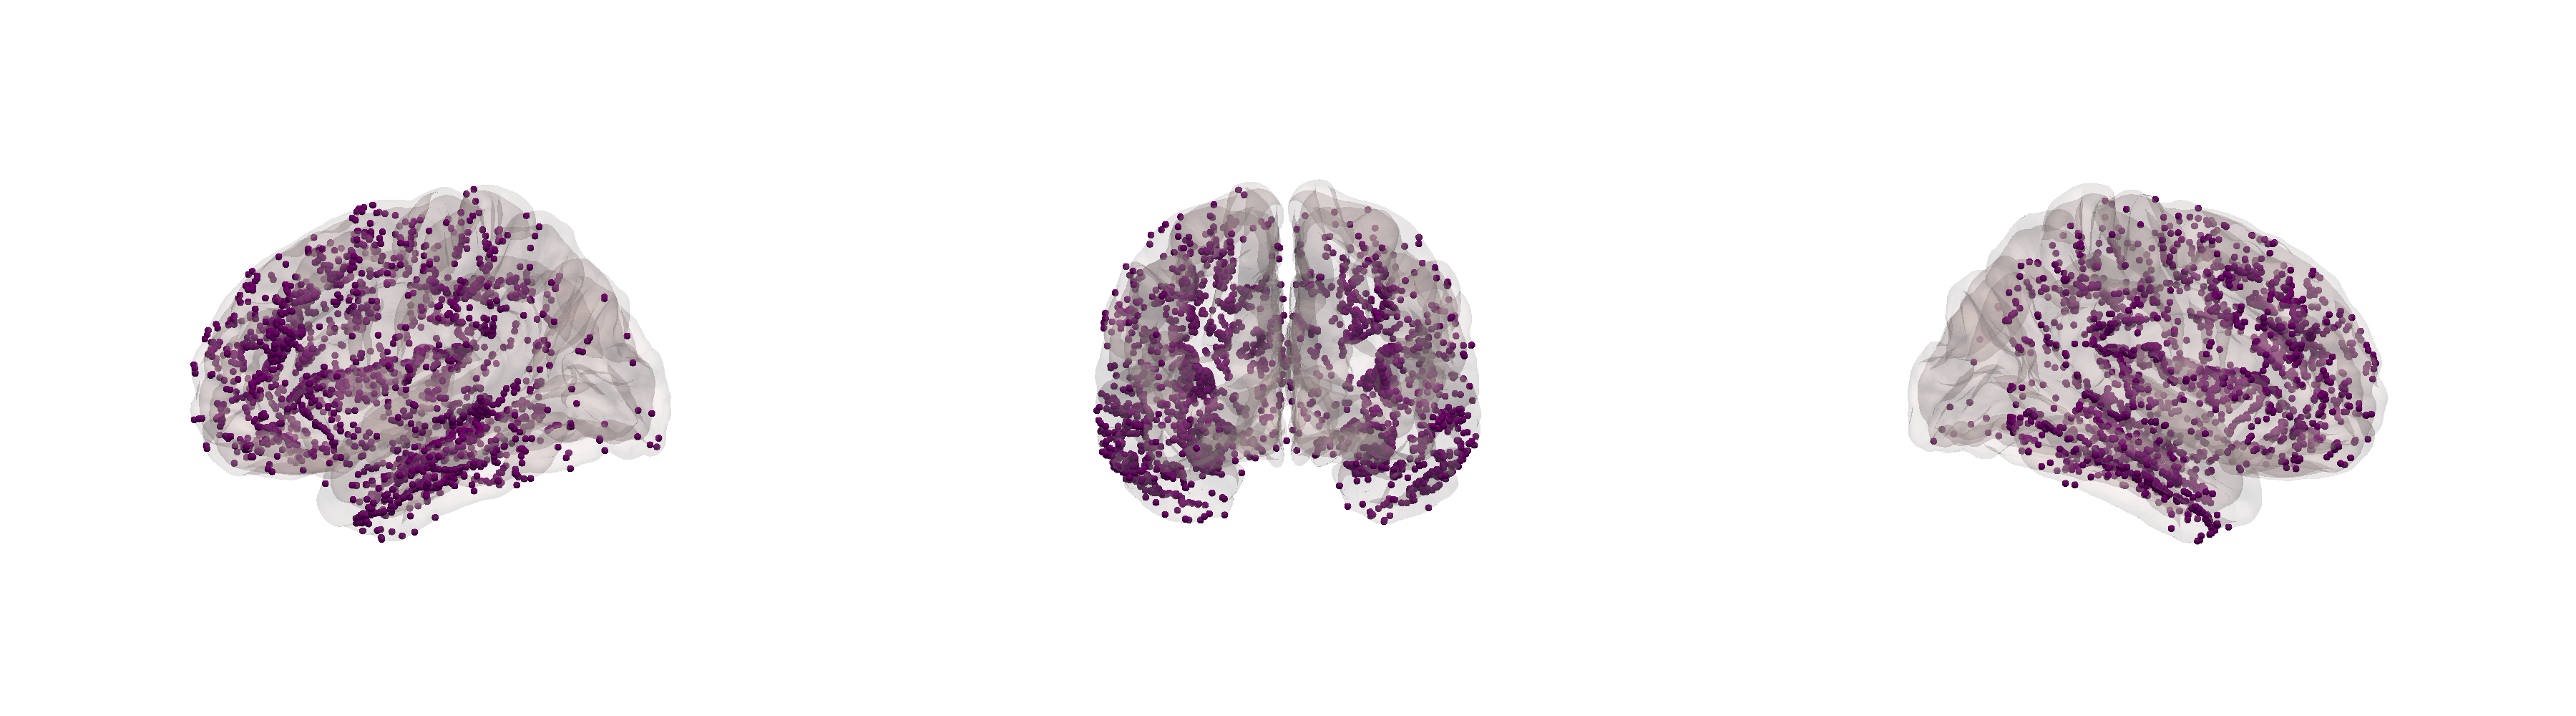
No white matter, only FBM patients PAT
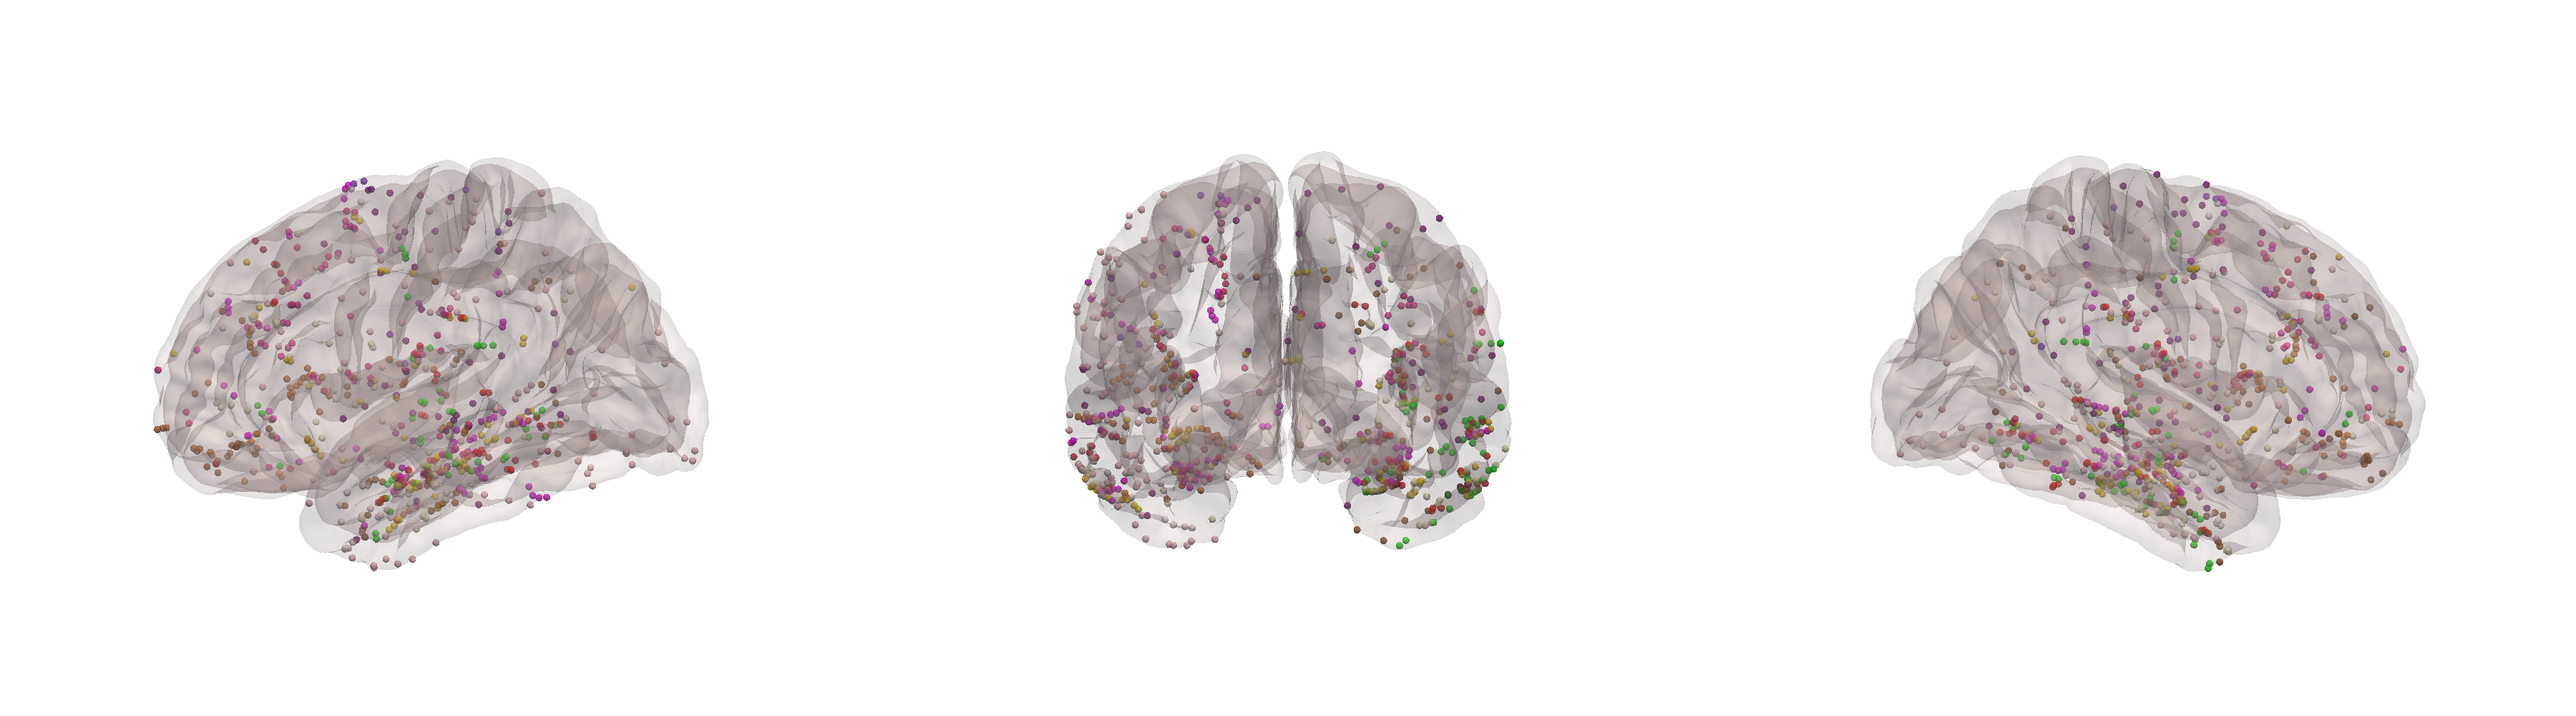



In [4]:
# PATIENTS_IGNORED = {"PAT_5515","PAT_648","PAT_699","PAT_1145","PAT_2856","PAT_2893"}
PATIENTS_IGNORED = {"PAT_648","PAT_699","PAT_1145","PAT_2856","PAT_2893"}


In [5]:
# ============================================================
# 1) FSAVERAGE cortical group plot (surface-based), WM excluded
# Inputs:
#   - OUT_ROOT/PAT_XXXX/glassbrain/coords/PAT_XXXX_contacts_tkrRAS.csv
#   - SHARED_ROOT/PAT_XXXX/mri/aseg.mgz
#   - SHARED_ROOT/PAT_XXXX/surf/{lh.pial,rh.pial,lh.sphere.reg,rh.sphere.reg}
#   - SHARED_ROOT/fsaverage/surf/{lh.pial,rh.pial,lh.sphere.reg,rh.sphere.reg}
#
# Outputs:
#   - OUT_ROOT/fsaverage/coords/PAT_XXXX_contacts_fsaverage_nowm.csv
#   - OUT_ROOT/fsaverage/coords/ALL_PATIENTS_contacts_fsaverage_nowm.csv
#   - OUT_ROOT/fsaverage/png/ALL_PATIENTS_fsaverage_mosaic_colorcoded_nowm.png
#   - OUT_ROOT/qc/WM_contacts_per_patient.csv
#   - OUT_ROOT/qc/WM_contacts_all_patients.csv
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import pyvista as pv
import imageio.v3 as iio
from nibabel.freesurfer.io import read_geometry
from scipy.spatial import cKDTree

# -------------------------
# PATHS
# -------------------------
SHARED_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators")
OUT_ROOT    = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon")
FSAVERAGE   = SHARED_ROOT / "fsaverage"

# -------------------------
# VIS
# -------------------------
PATIENT_COLORS = ["blueviolet","fuchsia","deeppink","crimson","pink","red","chocolate","gold","purple",
                  "saddlebrown","lemonchiffon","lavenderblush","lime","powderblue","forestgreen","lightcyan"]

WINDOW_SIZE = (1200, 1000)
TRANSPARENT_BG = True
BRAIN_COLOR = "#ead6db"
BRAIN_OPACITY = 0.25
POINT_SIZE = 10

# -------------------------
# WM definition in aseg
# (FreeSurfer aseg labels)
#  2  Left-Cerebral-White-Matter
# 41  Right-Cerebral-White-Matter
#  7  Left-Cerebellum-White-Matter
# 46  Right-Cerebellum-White-Matter
# -------------------------
WM_LABELS_ASEG = {2, 41, 7, 46}

def make_mesh(v, f):
    return pv.PolyData(v, np.c_[np.full(len(f), 3), f].astype(np.int64))

def stitch_horiz(imgs):
    H = min(im.shape[0] for im in imgs)
    return np.concatenate([im[:H] for im in imgs], axis=1)

def set_view(pl, view):
    if view == "left":
        pl.view_yz(negative=True)
    elif view == "right":
        pl.view_yz(negative=False)
    else:
        pl.view_xz()
    pl.camera.zoom(1.15)

def render_fsaverage_colorcoded(df_all_fs):
    # fsaverage meshes
    fs_lh_v, fs_lh_f = read_geometry(str(FSAVERAGE / "surf" / "lh.pial"))
    fs_rh_v, fs_rh_f = read_geometry(str(FSAVERAGE / "surf" / "rh.pial"))
    lh_mesh = make_mesh(fs_lh_v, fs_lh_f)
    rh_mesh = make_mesh(fs_rh_v, fs_rh_f)

    views = []
    for view in ("left", "frontal", "right"):
        pl = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
        pl.set_background("white")
        pl.add_mesh(lh_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY, smooth_shading=True)
        pl.add_mesh(rh_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY, smooth_shading=True)

        patients = sorted(df_all_fs["patient"].unique())
        for i, pid in enumerate(patients):
            dfp = df_all_fs[df_all_fs["patient"] == pid]
            pts = dfp[["x","y","z"]].to_numpy(float)
            pl.add_points(pts, color=PATIENT_COLORS[i % len(PATIENT_COLORS)],
                          point_size=POINT_SIZE, render_points_as_spheres=True, opacity=0.9)

        pl.reset_camera()
        set_view(pl, "left" if view=="left" else ("right" if view=="right" else "frontal"))
        img = pl.screenshot(transparent_background=TRANSPARENT_BG, return_img=True)
        pl.close()
        views.append(img)

    return stitch_horiz(views)

def classify_wm_from_aseg(subj_dir: Path, points_tkr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    points_tkr: N x 3 in tkrRAS (same space as aseg vox2ras_tkr)
    returns:
      is_wm (bool N)
      aseg_label (int N)
    """
    aseg_path = subj_dir / "mri" / "aparc+aseg.mgz"
    if not aseg_path.is_file():
        raise FileNotFoundError(f"Missing aseg: {aseg_path}")

    img = nib.load(str(aseg_path))
    data = np.asanyarray(img.dataobj)
    vox2ras_tkr = img.header.get_vox2ras_tkr()
    ras2vox_tkr = np.linalg.inv(vox2ras_tkr)

    n = points_tkr.shape[0]
    pts_h = np.c_[points_tkr, np.ones(n)]
    ijk = (ras2vox_tkr @ pts_h.T).T[:, :3]
    ijk = np.round(ijk).astype(int)

    # in-bounds mask
    shp = np.array(data.shape[:3], dtype=int)
    inb = (ijk[:,0] >= 0) & (ijk[:,0] < shp[0]) & (ijk[:,1] >= 0) & (ijk[:,1] < shp[1]) & (ijk[:,2] >= 0) & (ijk[:,2] < shp[2])

    labels = np.full(n, -1, dtype=int)
    labels[inb] = data[ijk[inb,0], ijk[inb,1], ijk[inb,2]].astype(int)

    is_wm = np.isin(labels, list(WM_LABELS_ASEG))
    return is_wm, labels

# -------------------------
# Load fsaverage spheres (for mapping)
# -------------------------
fs_lh_sph, _ = read_geometry(str(FSAVERAGE / "surf" / "lh.sphere.reg"))
fs_rh_sph, _ = read_geometry(str(FSAVERAGE / "surf" / "rh.sphere.reg"))
fs_lh_kd = cKDTree(fs_lh_sph)
fs_rh_kd = cKDTree(fs_rh_sph)

fs_lh_v, _ = read_geometry(str(FSAVERAGE / "surf" / "lh.pial"))
fs_rh_v, _ = read_geometry(str(FSAVERAGE / "surf" / "rh.pial"))

# -------------------------
# Main
# -------------------------
wm_rows_all = []
fs_rows_all = []

PATIENTS_IGNORED = {}
patient_ids = sorted([p.name for p in OUT_ROOT.iterdir() if p.is_dir() and p.name.startswith("PAT_") and p.name not in PATIENTS_IGNORED])

for pid in patient_ids:
    subj_dir = SHARED_ROOT / pid
    csv_in = OUT_ROOT / pid / "glassbrain" / "coords" / f"{pid}_contacts_tkrRAS.csv"
    if not csv_in.is_file():
        print(f"[SKIP] {pid}: missing {csv_in}")
        continue

    # patient surfaces/spheres
    lh_v, _   = read_geometry(str(subj_dir / "surf" / "lh.pial"))
    rh_v, _   = read_geometry(str(subj_dir / "surf" / "rh.pial"))
    lh_sph, _ = read_geometry(str(subj_dir / "surf" / "lh.sphere.reg"))
    rh_sph, _ = read_geometry(str(subj_dir / "surf" / "rh.sphere.reg"))

    # KD for hemi decision (nearest pial)
    lh_kd = cKDTree(lh_v)
    rh_kd = cKDTree(rh_v)

    df = pd.read_csv(csv_in)
    pts_tkr = df[["x","y","z"]].to_numpy(float)

    # WM classify (native space)
    is_wm, aseg_label = classify_wm_from_aseg(subj_dir, pts_tkr)

    # save WM list rows
    df_wm = df[is_wm].copy()
    if len(df_wm):
        df_wm["patient"] = pid
        df_wm["aseg_label"] = aseg_label[is_wm]
        wm_rows_all.append(df_wm[["patient","name","name_raw","x","y","z","aseg_label"]])

    # keep only non-WM for mapping + plotting
    keep = ~is_wm
    if keep.sum() == 0:
        print(f"[WARN] {pid}: all contacts in WM (by aseg). Skipping mapping.")
        continue

    df2 = df.loc[keep].copy()
    pts = pts_tkr[keep]

    rows_out = []
    for i, p in enumerate(pts):
        dl, il = lh_kd.query(p)
        dr, ir = rh_kd.query(p)

        if dl <= dr:
            hemi = "L"
            vtx = il
            sph = lh_sph[vtx]
            _, fs_vtx = fs_lh_kd.query(sph)
            fs_xyz = fs_lh_v[fs_vtx]
        else:
            hemi = "R"
            vtx = ir
            sph = rh_sph[vtx]
            _, fs_vtx = fs_rh_kd.query(sph)
            fs_xyz = fs_rh_v[fs_vtx]

        rows_out.append({
            "patient": pid,
            "name": df2.iloc[i]["name"],
            "name_raw": df2.iloc[i].get("name_raw", df2.iloc[i]["name"]),
            "hemi": hemi,
            "x": float(fs_xyz[0]),
            "y": float(fs_xyz[1]),
            "z": float(fs_xyz[2]),
        })

    df_fs = pd.DataFrame(rows_out)

    # per-patient save
    out_coords = OUT_ROOT / "fsaverage" / "coords"
    out_coords.mkdir(parents=True, exist_ok=True)
    out_csv = out_coords / f"{pid}_contacts_fsaverage_nowm.csv"
    df_fs.to_csv(out_csv, index=False)
    fs_rows_all.append(df_fs)

    print(f"[OK] {pid}: kept {len(df_fs)} non-WM contacts -> {out_csv}")

# Save WM lists
qc_dir = OUT_ROOT / "qc"
qc_dir.mkdir(parents=True, exist_ok=True)

if wm_rows_all:
    df_wm_all = pd.concat(wm_rows_all, ignore_index=True)
else:
    df_wm_all = pd.DataFrame(columns=["patient","name","name_raw","x","y","z","aseg_label"])

df_wm_all.to_csv(qc_dir / "WM_contacts_all_patients.csv", index=False)
# also per-patient table in one file (already has patient column)
df_wm_all.to_csv(qc_dir / "WM_contacts_per_patient.csv", index=False)

# Combine fsaverage and render
df_all_fs = pd.concat(fs_rows_all, ignore_index=True)
df_all_fs.to_csv(OUT_ROOT / "fsaverage" / "coords" / "ALL_PATIENTS_contacts_fsaverage_nowm.csv", index=False)

mosaic = render_fsaverage_colorcoded(df_all_fs)
png_dir = OUT_ROOT / "fsaverage" / "png"
png_dir.mkdir(parents=True, exist_ok=True)
png_out = png_dir / "ALL_PATIENTS_fsaverage_mosaic_colorcoded_nowm.png"
iio.imwrite(png_out, mosaic)

print(f"\nSaved fsaverage group plot (non-WM) -> {png_out}")
print(f"Saved WM lists -> {qc_dir / 'WM_contacts_all_patients.csv'}")


[OK] PAT_1145: kept 30 non-WM contacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\fsaverage\coords\PAT_1145_contacts_fsaverage_nowm.csv
[OK] PAT_2856: kept 65 non-WM contacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\fsaverage\coords\PAT_2856_contacts_fsaverage_nowm.csv
[OK] PAT_2868: kept 8 non-WM contacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\fsaverage\coords\PAT_2868_contacts_fsaverage_nowm.csv
[OK] PAT_2893: kept 57 non-WM contacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\fsaverage\coords\PAT_2893_contacts_fsaverage_nowm.csv
[OK] PAT_3066: kept 65 non-WM contacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\fsaverage\coords\PAT_3066_contacts_fsaverage_nowm.csv
[OK] PAT_3301: kept 4

## 250_recon/talairach outputs (WIP)
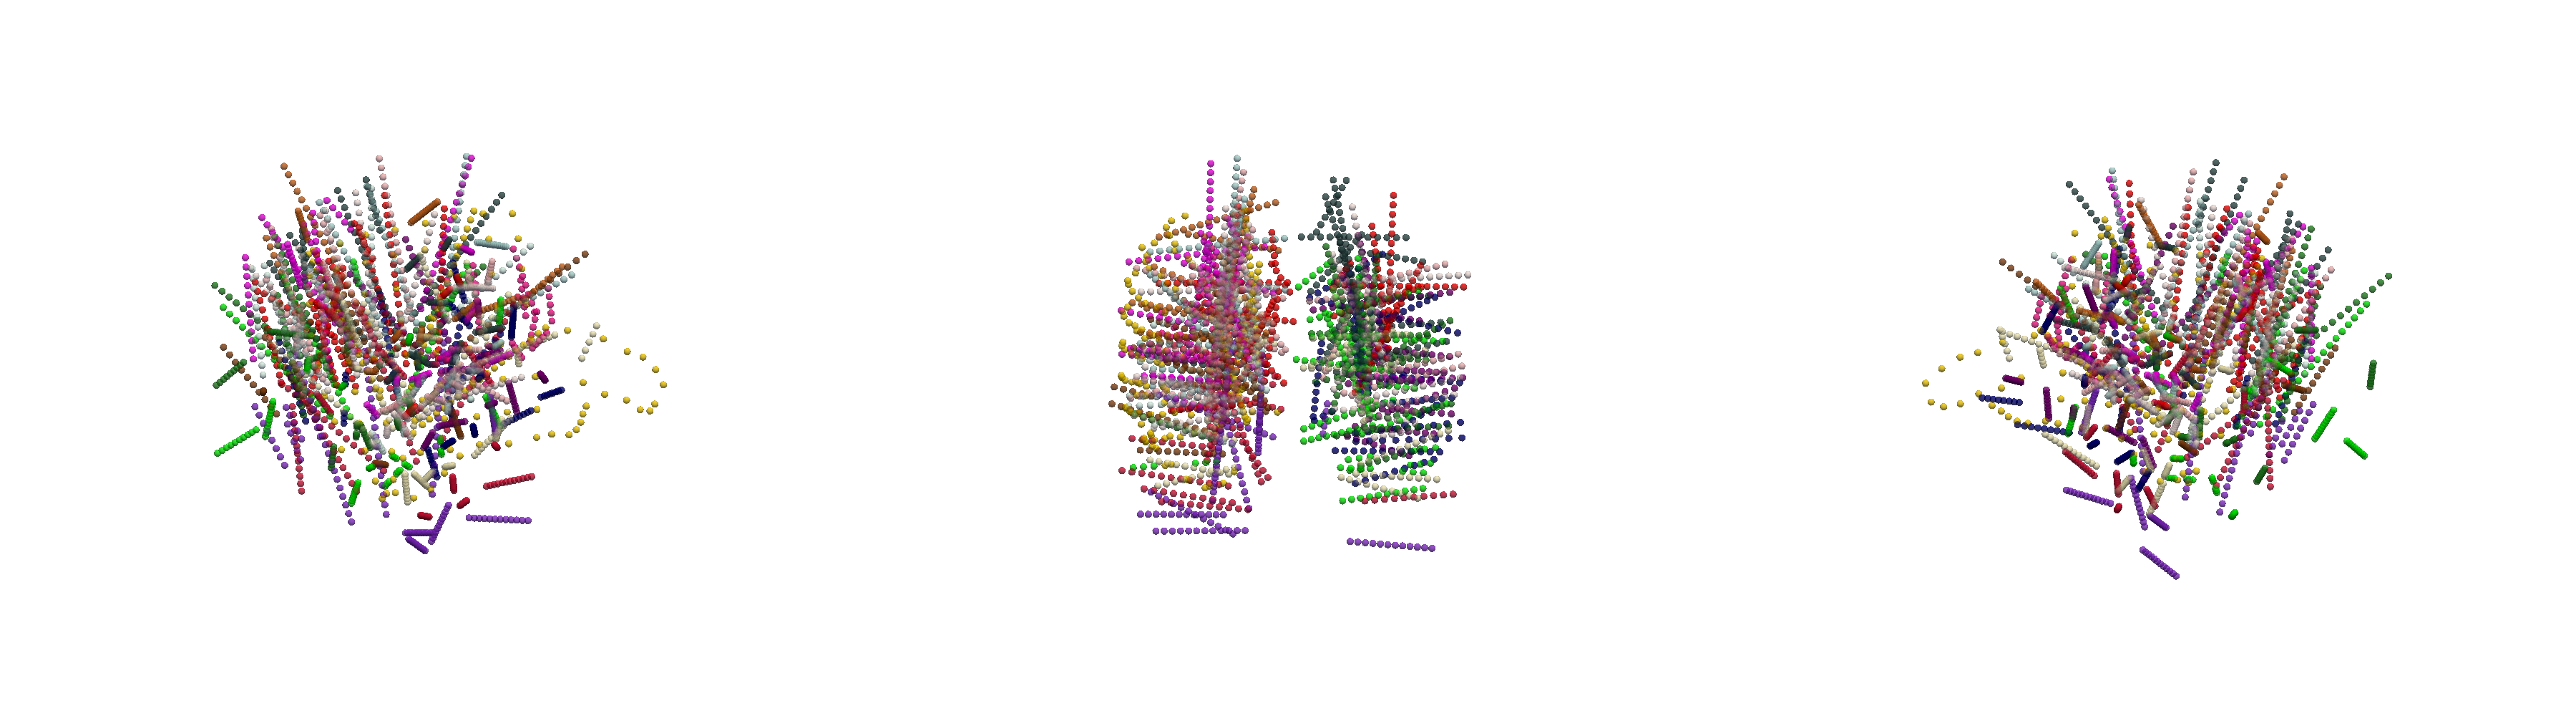

In [1]:
# PATIENTS_IGNORED = {"PAT_5515","PAT_648","PAT_699","PAT_1145","PAT_2856","PAT_2893"}
PATIENTS_IGNORED = {"PAT_648","PAT_699","PAT_1145","PAT_2856","PAT_2893"}


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import pyvista as pv
import imageio.v3 as iio

# ============================================================
# PATHS
# ============================================================
SHARED_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators")
OUT_ROOT    = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon")
FSAVERAGE   = SHARED_ROOT / "fsaverage"

# ============================================================
# SETTINGS
# ============================================================
PATIENT_COLORS = ["blueviolet","fuchsia","deeppink","crimson","pink","red","chocolate","gold","purple",
                  "saddlebrown","lemonchiffon","lavenderblush","lime","powderblue","forestgreen","lightcyan"]

WINDOW_SIZE = (1200, 1000)
TRANSPARENT_BG = True
BRAIN_COLOR = "#ead6db"
BRAIN_OPACITY = 0.20
POINT_SIZE = 10

# Optional ignore list
PATIENTS_IGNORED = set([
    # "PAT_1145",
])

# WM labels in (a)seg volumes (FreeSurfer)
WM_LABELS = {2, 41, 7, 46}  # L/R cerebral WM + L/R cerebellar WM

# ============================================================
# UTIL: talairach.xfm parser
# ============================================================
def load_talairach_xfm(xfm_path: Path) -> np.ndarray:
    lines = xfm_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    start = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("Linear_Transform"):
            start = i + 1
            break
    if start is None:
        raise RuntimeError(f"Could not find Linear_Transform in {xfm_path}")

    rows = []
    for j in range(3):
        raw = lines[start + j].strip()
        parts = [p.rstrip(";") for p in raw.split()]
        if len(parts) != 4:
            raise RuntimeError(f"Invalid transform row in {xfm_path}: {raw}")
        rows.append([float(p) for p in parts])

    M = np.eye(4)
    M[:3, :4] = np.array(rows, dtype=float)
    return M

def apply_affine(points_xyz: np.ndarray, M: np.ndarray) -> np.ndarray:
    n = points_xyz.shape[0]
    xyz_h = np.c_[points_xyz, np.ones(n)]
    out = (M @ xyz_h.T).T
    return out[:, :3]

# ============================================================
# UTIL: aparc+aseg voxel lookup in tkrRAS
# ============================================================
def lookup_aparc_aseg_labels(subj_dir: Path, points_tkr: np.ndarray):
    """
    Returns:
      label_id : int array (N,) from aparc+aseg.mgz
      is_wm    : bool array (N,) (100% WM at that voxel)
    """
    vol_path = subj_dir / "mri" / "aparc+aseg.mgz"
    if not vol_path.is_file():
        raise FileNotFoundError(f"Missing aparc+aseg: {vol_path}")

    img = nib.load(str(vol_path))
    vol = np.asanyarray(img.dataobj)
    vox2ras_tkr = img.header.get_vox2ras_tkr()
    ras2vox_tkr = np.linalg.inv(vox2ras_tkr)

    n = points_tkr.shape[0]
    pts_h = np.c_[points_tkr, np.ones(n)]
    ijk = (ras2vox_tkr @ pts_h.T).T[:, :3]
    ijk = np.round(ijk).astype(int)

    shp = np.array(vol.shape[:3], dtype=int)
    inb = (
        (ijk[:,0] >= 0) & (ijk[:,0] < shp[0]) &
        (ijk[:,1] >= 0) & (ijk[:,1] < shp[1]) &
        (ijk[:,2] >= 0) & (ijk[:,2] < shp[2])
    )

    label_id = np.full(n, -1, dtype=int)
    label_id[inb] = vol[ijk[inb,0], ijk[inb,1], ijk[inb,2]].astype(int)

    is_wm = np.isin(label_id, list(WM_LABELS))
    return label_id, is_wm

# ============================================================
# UTIL: build template brain mesh from fsaverage brainmask.mgz
# ============================================================
def build_template_brain_surface_from_fsaverage(out_vtk: Path) -> pv.PolyData:
    if out_vtk.is_file():
        return pv.read(str(out_vtk))

    brainmask = FSAVERAGE / "mri" / "brainmask.mgz"
    if not brainmask.is_file():
        raise FileNotFoundError(f"Missing template volume: {brainmask}")

    img = nib.load(str(brainmask))
    vol = np.asanyarray(img.dataobj)
    vox2ras = img.affine

    # PyVista ImageData: dimensions are points, so +1
    grid = pv.ImageData(dimensions=np.array(vol.shape) + 1)
    grid.spacing = (1.0, 1.0, 1.0)
    grid.origin = (0.0, 0.0, 0.0)

    # assign as cell data then convert to point data
    grid.cell_data["mask"] = vol.flatten(order="F")
    grid = grid.cell_data_to_point_data()

    surf = grid.contour(isosurfaces=[0.5], scalars="mask")

    # voxel -> RAS
    pts = surf.points
    pts_h = np.c_[pts, np.ones(len(pts))]
    ras = (vox2ras @ pts_h.T).T[:, :3]
    surf.points = ras

    out_vtk.parent.mkdir(parents=True, exist_ok=True)
    surf.save(str(out_vtk))
    return surf

# ============================================================
# UTIL: rendering helpers
# ============================================================
def stitch_horiz(imgs):
    H = min(im.shape[0] for im in imgs)
    return np.concatenate([im[:H] for im in imgs], axis=1)

def set_view(pl, view):
    if view == "left":
        pl.view_yz(negative=True)
    elif view == "right":
        pl.view_yz(negative=False)
    else:
        pl.view_xz()
    pl.camera.zoom(1.15)

def render_talairach_by_patient(df_all, brain_mesh):
    views = []
    patients = sorted(df_all["patient"].dropna().unique())
    for view in ("left", "frontal", "right"):
        pl = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
        pl.set_background("white")
        pl.add_mesh(brain_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY)

        for i, pid in enumerate(patients):
            dfp = df_all[df_all["patient"] == pid]
            pts = dfp[["x","y","z"]].to_numpy(float)
            if len(pts) == 0:
                continue
            pl.add_points(pts, color=PATIENT_COLORS[i % len(PATIENT_COLORS)],
                          point_size=POINT_SIZE, render_points_as_spheres=True, opacity=0.9)

        pl.reset_camera()
        set_view(pl, "left" if view=="left" else ("right" if view=="right" else "frontal"))
        img = pl.screenshot(transparent_background=TRANSPARENT_BG, return_img=True)
        pl.close()
        views.append(img)
    return stitch_horiz(views)

def render_talairach_by_parcel_id(df_all, brain_mesh):
    """
    Colors by parcel_id using a stable hash->color mapping so it's reproducible.
    No LUT required.
    """
    # unique parcel IDs excluding invalids
    parcel_ids = sorted([int(x) for x in df_all["parcel_id"].unique() if int(x) >= 0])

    def id_to_rgb(pid: int):
        # deterministic pseudo-random color from id
        rng = np.random.RandomState(pid % (2**32 - 1))
        c = rng.rand(3)
        # avoid too-dark colors
        c = 0.25 + 0.75 * c
        return tuple(c.tolist())

    views = []
    for view in ("left", "frontal", "right"):
        pl = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
        pl.set_background("white")
        pl.add_mesh(brain_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY)

        for pid in parcel_ids:
            dfp = df_all[df_all["parcel_id"] == pid]
            pts = dfp[["x","y","z"]].to_numpy(float)
            if len(pts) == 0:
                continue
            pl.add_points(pts, color=id_to_rgb(pid),
                          point_size=POINT_SIZE, render_points_as_spheres=True, opacity=0.9)

        pl.reset_camera()
        set_view(pl, "left" if view=="left" else ("right" if view=="right" else "frontal"))
        img = pl.screenshot(transparent_background=TRANSPARENT_BG, return_img=True)
        pl.close()
        views.append(img)
    return stitch_horiz(views)

# ============================================================
# MAIN
# ============================================================
tmpl_dir = OUT_ROOT / "talairach" / "template"
tmpl_mesh_path = tmpl_dir / "fsaverage_brainmask_surface.vtk"
brain_mesh = build_template_brain_surface_from_fsaverage(tmpl_mesh_path)

wm_rows_all = []
tal_rows_all = []

all_pat_dirs = sorted([p for p in OUT_ROOT.iterdir() if p.is_dir() and p.name.startswith("PAT_")])
patient_ids = sorted([p.name for p in OUT_ROOT.iterdir() if p.is_dir() and p.name.startswith("PAT_") and p.name not in PATIENTS_IGNORED])

for pid in patient_ids:
    subj_dir = SHARED_ROOT / pid
    csv_in = OUT_ROOT / pid / "glassbrain" / "coords" / f"{pid}_contacts_tkrRAS.csv"
    xfm    = subj_dir / "mri" / "transforms" / "talairach.xfm"

    if not csv_in.is_file():
        print(f"[SKIP] {pid}: missing {csv_in}")
        continue
    if not xfm.is_file():
        print(f"[SKIP] {pid}: missing {xfm}")
        continue

    df = pd.read_csv(csv_in)
    pts_tkr = df[["x","y","z"]].to_numpy(float)

    # parcel IDs + WM (from aparc+aseg)
    parcel_id, is_wm = lookup_aparc_aseg_labels(subj_dir, pts_tkr)

    # save WM list
    if is_wm.any():
        df_wm = df.loc[is_wm].copy()
        df_wm["patient"] = pid
        df_wm["parcel_id_native"] = parcel_id[is_wm]
        wm_rows_all.append(df_wm)

    # keep non-WM
    keep = ~is_wm
    if keep.sum() == 0:
        print(f"[WARN] {pid}: all contacts WM by aparc+aseg voxel. Skipping.")
        continue

    df2 = df.loc[keep].copy()
    pts2 = pts_tkr[keep]

    # native parcel ids stored
    df2["parcel_id_native"] = parcel_id[keep]

    # transform to Talairach/MNI-style
    M = load_talairach_xfm(xfm)
    pts_tal = apply_affine(pts2, M)

    df2[["x","y","z"]] = pts_tal
    df2["patient"] = pid
    df2["space"] = "Talairach"
    df2["transform"] = "FreeSurfer talairach.xfm"

    # for plotting/annotation in template space
    df2["parcel_id"] = df2["parcel_id_native"].astype(int)

    out_coords = OUT_ROOT / "talairach" / "coords"
    out_coords.mkdir(parents=True, exist_ok=True)
    out_csv = out_coords / f"{pid}_contacts_talairach_nowm_with_parcelID.csv"
    df2.to_csv(out_csv, index=False)

    tal_rows_all.append(df2)
    print(f"[OK] {pid}: kept {len(df2)} non-WM -> {out_csv}")

# Save WM lists
qc_dir = OUT_ROOT / "qc"
qc_dir.mkdir(parents=True, exist_ok=True)

if wm_rows_all:
    df_wm_all = pd.concat(wm_rows_all, ignore_index=True)
else:
    df_wm_all = pd.DataFrame()

wm_out = qc_dir / "WM_contacts_all_patients_aparcAseg.csv"
df_wm_all.to_csv(wm_out, index=False)
print(f"\nSaved WM list -> {wm_out}")

# Combine Talairach
df_all_tal = pd.concat(tal_rows_all, ignore_index=True)
all_csv = OUT_ROOT / "talairach" / "coords" / "ALL_PATIENTS_contacts_talairach_nowm_with_parcelID.csv"
df_all_tal.to_csv(all_csv, index=False)
print(f"Saved combined Talairach -> {all_csv}")

# PNG 1: color by patient (QC)
png_dir = OUT_ROOT / "talairach" / "png"
png_dir.mkdir(parents=True, exist_ok=True)

mosaic_patient = render_talairach_by_patient(df_all_tal, brain_mesh)
png_patient = png_dir / "ALL_PATIENTS_talairach_with_brain_color_by_patient_nowm.png"
iio.imwrite(png_patient, mosaic_patient)
print(f"Saved PNG (by patient) -> {png_patient}")

# PNG 2: color by parcel_id (annotation)
mosaic_parcel = render_talairach_by_parcel_id(df_all_tal, brain_mesh)
png_parcel = png_dir / "ALL_PATIENTS_talairach_with_brain_color_by_parcelID_nowm.png"
iio.imwrite(png_parcel, mosaic_parcel)
print(f"Saved PNG (by parcel_id) -> {png_parcel}")


[OK] PAT_1145: kept 30 non-WM -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\coords\PAT_1145_contacts_talairach_nowm_with_parcelID.csv
[OK] PAT_2856: kept 65 non-WM -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\coords\PAT_2856_contacts_talairach_nowm_with_parcelID.csv
[OK] PAT_2868: kept 8 non-WM -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\coords\PAT_2868_contacts_talairach_nowm_with_parcelID.csv
[OK] PAT_2893: kept 57 non-WM -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\coords\PAT_2893_contacts_talairach_nowm_with_parcelID.csv
[OK] PAT_3066: kept 65 non-WM -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\coords\PAT_3066_contacts_talairach_nowm_with_parcelID.

## 250_recon/  talaraich on fsaverage mesh

In [7]:
# ============================================================
# PLOTS (3 outputs)
#   A) fsaverage surface plot (publication-quality cortex view)
#   B) Talairach points-only plot (true 3D; depth-friendly QC)
#   C) Hybrid: fsaverage surface (very faint) + Talairach points
#      (presentation/intuitive ONLY — not a true common-space overlay)
#
# Assumes you already saved:
#   - fsaverage coords CSV:  ...\250_recon\fsaverage\coords\ALL_PATIENTS_contacts_fsaverage_nowm.csv
#   - talairach coords CSV:  ...\250_recon\talairach\coords\ALL_PATIENTS_contacts_talairach_nowm_with_parcelID.csv
#
# Output PNGs go to:
#   ...\250_recon\fsaverage\png\
#   ...\250_recon\talairach\png\
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pyvista as pv
import imageio.v3 as iio
from nibabel.freesurfer.io import read_geometry

# -------------------------
# PATHS
# -------------------------
SHARED_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators")
OUT_ROOT    = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon")
FSAVERAGE   = SHARED_ROOT / "fsaverage"

FS_CSV  = OUT_ROOT / "fsaverage" / "coords" / "ALL_PATIENTS_contacts_fsaverage_nowm.csv"
TAL_CSV = OUT_ROOT / "talairach" / "coords" / "ALL_PATIENTS_contacts_talairach_nowm_with_parcelID.csv"

# -------------------------
# SETTINGS
# -------------------------
PATIENT_COLORS = ["blueviolet","fuchsia","deeppink","crimson","pink","red","chocolate","gold","purple",
                  "saddlebrown","lemonchiffon","lavenderblush","lime","powderblue","forestgreen","lightcyan"]

WINDOW_SIZE = (1200, 1000)
TRANSPARENT_BG = True

BRAIN_COLOR = "#ead6db"
FS_BRAIN_OPACITY = 0.28     # pretty cortex view
HY_BRAIN_OPACITY = 0.08     # very faint for hybrid
POINT_SIZE = 10


# -------------------------
# Helpers
# -------------------------
def make_mesh(v, f):
    return pv.PolyData(v, np.c_[np.full(len(f), 3), f].astype(np.int64))

def stitch_horiz(imgs):
    H = min(im.shape[0] for im in imgs)
    return np.concatenate([im[:H] for im in imgs], axis=1)

def set_view(pl, view):
    if view == "left":
        pl.view_yz(negative=True)
    elif view == "right":
        pl.view_yz(negative=False)
    else:
        pl.view_xz()
    pl.camera.zoom(1.15)

def add_points_by_patient(pl, df, size=POINT_SIZE, opacity=0.9):
    patients = sorted([p for p in df["patient"].dropna().unique() if p not in PATIENTS_IGNORED])
    for i, pid in enumerate(patients):
        dfp = df[df["patient"] == pid]
        pts = dfp[["x","y","z"]].to_numpy(float)
        if len(pts) == 0:
            continue
        pl.add_points(
            pts,
            color=PATIENT_COLORS[i % len(PATIENT_COLORS)],
            point_size=size,
            render_points_as_spheres=True,
            opacity=opacity,
        )

def render_three_views(backdrop_fn, points_fn):
    imgs = []
    for view in ("left", "frontal", "right"):
        pl = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
        pl.set_background("white")
        if backdrop_fn is not None:
            backdrop_fn(pl)
        points_fn(pl)
        pl.reset_camera()
        set_view(pl, "left" if view=="left" else ("right" if view=="right" else "frontal"))
        img = pl.screenshot(transparent_background=TRANSPARENT_BG, return_img=True)
        pl.close()
        imgs.append(img)
    return stitch_horiz(imgs)

def add_light_ellipsoid(pl, pts, opacity=0.08):
    # Robust scale anchor for points-only Talairach plot
    c = np.nanmedian(pts, axis=0)
    spread = np.nanpercentile(np.linalg.norm(pts - c, axis=1), 95)
    if not np.isfinite(spread) or spread <= 1:
        spread = 80.0
    ell = pv.ParametricEllipsoid(spread*1.1, spread*0.85, spread*0.9).triangulate()
    ell.translate(c, inplace=True)
    pl.add_mesh(ell, color=BRAIN_COLOR, opacity=opacity)

# -------------------------
# Load data
# -------------------------
df_fs  = pd.read_csv(FS_CSV)
df_tal = pd.read_csv(TAL_CSV)

# Ensure patient column exists
if "patient" not in df_fs.columns:
    raise RuntimeError(f"'patient' missing in {FS_CSV}")
if "patient" not in df_tal.columns:
    # try extract from name_raw/leptovox_file if present; otherwise fail
    if "leptovox_file" in df_tal.columns:
        df_tal["patient"] = df_tal["leptovox_file"].str.extract(r"(PAT_\d+)", expand=False)
    else:
        raise RuntimeError(f"'patient' missing in {TAL_CSV}")

# Apply ignore list
df_fs  = df_fs[~df_fs["patient"].isin(PATIENTS_IGNORED)].copy()
df_tal = df_tal[~df_tal["patient"].isin(PATIENTS_IGNORED)].copy()

# -------------------------
# Load fsaverage surfaces (pial)
# -------------------------
lh_v, lh_f = read_geometry(str(FSAVERAGE / "surf" / "lh.pial"))
rh_v, rh_f = read_geometry(str(FSAVERAGE / "surf" / "rh.pial"))
lh_mesh = make_mesh(lh_v, lh_f)
rh_mesh = make_mesh(rh_v, rh_f)

# ============================================================
# A) FSAVERAGE surface plot (cortex)
# ============================================================
def backdrop_fsaverage(pl):
    pl.add_mesh(lh_mesh, color=BRAIN_COLOR, opacity=FS_BRAIN_OPACITY, smooth_shading=True)
    pl.add_mesh(rh_mesh, color=BRAIN_COLOR, opacity=FS_BRAIN_OPACITY, smooth_shading=True)

def points_fsaverage(pl):
    add_points_by_patient(pl, df_fs, size=POINT_SIZE, opacity=0.9)

mosaic_fs = render_three_views(backdrop_fsaverage, points_fsaverage)
out_fs_png_dir = OUT_ROOT / "fsaverage" / "png"
out_fs_png_dir.mkdir(parents=True, exist_ok=True)
out_fs_png = out_fs_png_dir / "ALL_PATIENTS_fsaverage_surface_color_by_patient_nowm.png"
iio.imwrite(out_fs_png, mosaic_fs)
print(f"[OK] fsaverage surface plot -> {out_fs_png}")

# ============================================================
# B) TALAIRACH points-only plot (true 3D; depth QC)
# ============================================================
pts_tal = df_tal[["x","y","z"]].to_numpy(float)

def backdrop_tal_points_only(pl):
    add_light_ellipsoid(pl, pts_tal, opacity=0.08)

def points_tal(pl):
    add_points_by_patient(pl, df_tal, size=POINT_SIZE, opacity=0.9)

mosaic_tal_pts = render_three_views(backdrop_tal_points_only, points_tal)
out_tal_png_dir = OUT_ROOT / "talairach" / "png"
out_tal_png_dir.mkdir(parents=True, exist_ok=True)
out_tal_pts_png = out_tal_png_dir / "ALL_PATIENTS_talairach_points_only_color_by_patient_nowm.png"
iio.imwrite(out_tal_pts_png, mosaic_tal_pts)
print(f"[OK] talairach points-only plot -> {out_tal_pts_png}")

# ============================================================
# C) HYBRID plot (fsaverage surface faint + Talairach points)
#     NOTE: visually intuitive, NOT geometrically exact
# ============================================================
def backdrop_hybrid(pl):
    pl.add_mesh(lh_mesh, color=BRAIN_COLOR, opacity=HY_BRAIN_OPACITY, smooth_shading=True)
    pl.add_mesh(rh_mesh, color=BRAIN_COLOR, opacity=HY_BRAIN_OPACITY, smooth_shading=True)

mosaic_hybrid = render_three_views(backdrop_hybrid, points_tal)
out_hybrid_png = out_tal_png_dir / "ALL_PATIENTS_hybrid_fsaverage_surface_faint_plus_talairach_points.png"
iio.imwrite(out_hybrid_png, mosaic_hybrid)
print(f"[OK] hybrid plot (presentation/intuitive) -> {out_hybrid_png}")


[OK] fsaverage surface plot -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\fsaverage\png\ALL_PATIENTS_fsaverage_surface_color_by_patient_nowm.png
[OK] talairach points-only plot -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\png\ALL_PATIENTS_talairach_points_only_color_by_patient_nowm.png
[OK] hybrid plot (presentation/intuitive) -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon\talairach\png\ALL_PATIENTS_hybrid_fsaverage_surface_faint_plus_talairach_points.png


In [8]:


# ============================================================
# ONE CELL: LEPTOVOX -> tkrRAS with (perm + flips) search
#          hemi-aware scoring + save TOP-K candidate mosaics
#          so you can visually verify which is correct.
#
# Works with:
#   elec_recon/PAT_XXXX.LEPTOVOX
#   elec_recon/PAT_XXXX.electrodeNames  (first 2 lines are headers)
#   mri/brainmask.mgz (or T1/orig)
#   surf/lh.pial, surf/rh.pial
#
# Outputs per patient under OUT_ROOT/PAT_XXXX/glassbrain/:
#   coords/PAT_XXXX_contacts_tkrRAS.csv
#   png/PAT_XXXX_mosaic_LEPTOVOX.png                (best)
#   png_candidates/PAT_XXXX_cand01_...png ...       (top K)
#   png_candidates/PAT_XXXX_candidates_summary.csv  (table)
# ============================================================

from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import nibabel as nib
import pyvista as pv
import imageio.v3 as iio
from nibabel.freesurfer.io import read_geometry
from scipy.spatial import cKDTree


# -------------------------
# CONFIG
# -------------------------
SHARED_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\#SHARE\To_send_collaborators")
OUT_ROOT    = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\250_recon")

# scoring weights
LAMBDA_HEMI = 120.0   # mm penalty for hemisphere mismatch (increase if still mirrored)
K_CANDIDATES_TO_SAVE = 12  # how many candidate mosaics to save per patient

# render params
VIEWS = ("left", "frontal", "right")
WINDOW_SIZE = (1200, 1000)
TRANSPARENT_BG = True
BRAIN_COLOR = "#ead6db"
BRAIN_OPACITY = 0.25
POINT_COLOR = "purple"
POINT_SIZE = 10
POINT_OPACITY = 0.9

OVERWRITE_CSV = True
OVERWRITE_PNG = True
OVERWRITE_CANDIDATES = True


# -------------------------
# IO helpers
# -------------------------
def read_electrode_lines_drop2(path: Path) -> list[str]:
    """Return electrode lines after dropping 2 header lines."""
    lines = [ln.strip() for ln in path.read_text(encoding="utf-8", errors="ignore").splitlines() if ln.strip()]
    if len(lines) < 3:
        raise ValueError(f"electrodeNames too short: {path}")
    return lines[2:]

def parse_name_and_hemi(lines: list[str]):
    """
    lines look like: 'FPG1 D L' or 'FOG12 D R'
    We keep the whole line as 'name_raw' for traceability and also extract a clean name + hem label.
    """
    names_raw = []
    names_clean = []
    hemi = []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 1:
            nm = parts[0]
        else:
            nm = ln
        h = None
        # hem is often last token "L" or "R"
        if len(parts) >= 1:
            last = parts[-1].upper()
            if last in ("L", "R"):
                h = last
        names_raw.append(ln)
        names_clean.append(nm)
        hemi.append(h)
    return np.array(names_raw, dtype=object), np.array(names_clean, dtype=object), np.array(hemi, dtype=object)

def read_leptovox_xyz(path: Path) -> np.ndarray:
    rows = []
    for ln in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        t = ln.strip()
        if not t or t.startswith("#"):
            continue
        parts = t.replace(",", " ").split()
        if len(parts) < 3:
            continue
        try:
            rows.append((float(parts[0]), float(parts[1]), float(parts[2])))
        except ValueError:
            continue
    if not rows:
        raise ValueError(f"No numeric rows found in {path}")
    return np.asarray(rows, dtype=float)

def pick_mgz(subj_dir: Path) -> Path:
    for cand in ["brainmask.mgz", "T1.mgz", "orig.mgz"]:
        p = subj_dir / "mri" / cand
        if p.is_file():
            return p
    raise FileNotFoundError(f"Missing brainmask/T1/orig in {subj_dir/'mri'}")


# -------------------------
# Geometry / scoring helpers
# -------------------------
def voxel_to_tkr(points_ijk: np.ndarray, vox2ras_tkr: np.ndarray) -> np.ndarray:
    n = points_ijk.shape[0]
    ijk_h = np.c_[points_ijk, np.ones(n)]
    tkr_h = (vox2ras_tkr @ ijk_h.T).T
    return tkr_h[:, :3]

def nearest_pial_metrics(points_tkr: np.ndarray, lh_v: np.ndarray, rh_v: np.ndarray):
    kdl = cKDTree(lh_v)
    kdr = cKDTree(rh_v)
    dl, _ = kdl.query(points_tkr, k=1, workers=-1)
    dr, _ = kdr.query(points_tkr, k=1, workers=-1)
    is_left = dl <= dr
    dist = np.minimum(dl, dr)
    return dist, is_left

def apply_voxel_flips(ijk: np.ndarray, vol_shape, flips: tuple[bool,bool,bool]) -> np.ndarray:
    dims = np.array(vol_shape, dtype=float)
    out = ijk.copy()
    for ax, do_flip in enumerate(flips):
        if do_flip:
            out[:, ax] = (dims[ax] - 1.0) - out[:, ax]
    return out

def hemi_accuracy(pred_is_left: np.ndarray, hemi_expected: np.ndarray) -> float:
    """
    hemi_expected entries are 'L','R', or None
    pred_is_left is boolean array from nearest pial
    """
    mask = np.array([h in ("L","R") for h in hemi_expected], dtype=bool)
    if mask.sum() == 0:
        return np.nan
    exp_is_left = np.array([h == "L" for h in hemi_expected[mask]], dtype=bool)
    pred = pred_is_left[mask]
    return float(np.mean(pred == exp_is_left))

def choose_best_perm_and_flips(
    pts_ijk_raw: np.ndarray,
    vox2ras_tkr: np.ndarray,
    lh_v: np.ndarray,
    rh_v: np.ndarray,
    vol_shape,
    hemi_expected: np.ndarray,
    lambda_hemi: float,
):
    """
    Search over:
      - 6 perms of columns
      - 8 voxel flips (i, j, k)
    Score = median_dist_to_pial + lambda_hemi*(1 - hemi_acc)
      If hemi_expected missing => score = median_dist only.

    Returns sorted list of candidate dicts (best first).
    """
    dims = np.array(vol_shape, dtype=float)

    candidates = []
    perms = list(itertools.permutations([0,1,2], 3))
    flips_list = list(itertools.product([False, True], repeat=3))

    for perm in perms:
        base = pts_ijk_raw[:, perm]

        # early reject if totally out-of-bounds (with slack)
        if not ((base >= -5).all() and (base <= (dims + 5)).all()):
            continue

        for flips in flips_list:
            ijk = apply_voxel_flips(base, vol_shape, flips)

            # bound check again (allow slack)
            if not ((ijk >= -5).all() and (ijk <= (dims + 5)).all()):
                continue

            tkr = voxel_to_tkr(ijk, vox2ras_tkr)
            dist_mm, pred_is_left = nearest_pial_metrics(tkr, lh_v, rh_v)

            med = float(np.median(dist_mm))
            acc = hemi_accuracy(pred_is_left, hemi_expected)

            if np.isnan(acc):
                score = med
            else:
                score = med + lambda_hemi * (1.0 - acc)

            candidates.append({
                "perm": perm,
                "flips": flips,
                "median_dist_mm": med,
                "hemi_acc": acc,
                "score": float(score),
                "tkr": tkr,
                "dist": dist_mm,
                "pred_is_left": pred_is_left,
            })

    if not candidates:
        raise RuntimeError("No valid candidates found (all out-of-bounds).")

    candidates.sort(key=lambda d: d["score"])
    return candidates


# -------------------------
# Rendering helpers
# -------------------------
def make_mesh(v, f):
    return pv.PolyData(v, np.c_[np.full(len(f), 3), f].astype(np.int64))

def set_view(pl, view):
    view = view.lower()
    if view == "left":
        pl.view_yz(negative=True)
    elif view == "frontal":
        pl.view_xz(negative=False)
    elif view == "right":
        pl.view_yz(negative=False)
    else:
        raise ValueError(view)
    pl.camera.zoom(1.15)

def render_view(lh_mesh, rh_mesh, points_tkr, view):
    pl = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
    pl.set_background("white")
    pl.add_mesh(lh_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY, smooth_shading=True)
    pl.add_mesh(rh_mesh, color=BRAIN_COLOR, opacity=BRAIN_OPACITY, smooth_shading=True)
    pl.add_points(points_tkr, color=POINT_COLOR, render_points_as_spheres=True,
                  point_size=POINT_SIZE, opacity=POINT_OPACITY)
    set_view(pl, view)
    img = pl.screenshot(transparent_background=TRANSPARENT_BG, return_img=True)
    pl.close()
    return img

def stitch_horiz(imgs):
    H = min(im.shape[0] for im in imgs)
    imgs = [im[:H] for im in imgs]
    return np.concatenate(imgs, axis=1)


# -------------------------
# Core per-patient routine
# -------------------------
def export_and_mosaic_patient(pid: str):
    pid = str(pid)
    subj_dir = SHARED_ROOT / pid

    names_path = subj_dir / "elec_recon" / f"{pid}.electrodeNames"
    vox_path   = subj_dir / "elec_recon" / f"{pid}.LEPTOVOX"
    if not names_path.is_file():
        raise FileNotFoundError(f"missing {names_path}")
    if not vox_path.is_file():
        raise FileNotFoundError(f"missing {vox_path}")

    mgz = pick_mgz(subj_dir)
    img = nib.load(str(mgz))
    vox2ras_tkr = img.header.get_vox2ras_tkr()
    vol_shape = img.shape[:3]

    # surfaces
    lh_v, lh_f = read_geometry(str(subj_dir / "surf" / "lh.pial"))
    rh_v, rh_f = read_geometry(str(subj_dir / "surf" / "rh.pial"))
    lh_mesh = make_mesh(lh_v, lh_f)
    rh_mesh = make_mesh(rh_v, rh_f)

    # names + hemi labels
    lines = read_electrode_lines_drop2(names_path)
    names_raw, names_clean, hemi = parse_name_and_hemi(lines)

    # LEPTOVOX coords
    pts = read_leptovox_xyz(vox_path)
    if pts.shape[0] != len(names_raw):
        raise RuntimeError(f"{pid}: LEPTOVOX rows ({pts.shape[0]}) != electrodeNames contacts ({len(names_raw)})")

    # 0/1-based detection
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    dims = np.array(vol_shape, dtype=float)
    looks_one_based  = (mins >= 1).all() and (maxs <= dims).all()
    looks_zero_based = (mins >= 0).all() and (maxs <  dims).all()

    pts_ijk_raw = pts.copy()
    index_mode = "0-based (assumed)"
    if looks_one_based and not looks_zero_based:
        pts_ijk_raw -= 1.0
        index_mode = "1-based->0-based"

    # candidate search (perm + flips) with hemi-aware scoring
    cands = choose_best_perm_and_flips(
        pts_ijk_raw, vox2ras_tkr, lh_v, rh_v, vol_shape, hemi,
        lambda_hemi=LAMBDA_HEMI,
    )

    best = cands[0]
    pts_tkr = best["tkr"]
    dist_mm = best["dist"]
    pred_is_left = best["pred_is_left"]

    # outputs
    out_coords = OUT_ROOT / pid / "glassbrain" / "coords"
    out_pngdir = OUT_ROOT / pid / "glassbrain" / "png"
    out_candir = OUT_ROOT / pid / "glassbrain" / "png_candidates"
    out_coords.mkdir(parents=True, exist_ok=True)
    out_pngdir.mkdir(parents=True, exist_ok=True)
    out_candir.mkdir(parents=True, exist_ok=True)

    out_csv = out_coords / f"{pid}_contacts_tkrRAS.csv"
    out_png = out_pngdir / f"{pid}_mosaic_LEPTOVOX.png"

    # Save best CSV
    if OVERWRITE_CSV or (not out_csv.is_file()):
        df_out = pd.DataFrame({
            "name_raw": names_raw,     # e.g. "FPG1 D L"
            "name": names_clean,       # e.g. "FPG1"
            "hemi_expected": hemi,     # L/R/None
            "x": pts_tkr[:,0], "y": pts_tkr[:,1], "z": pts_tkr[:,2],
            "pred_isLeft": pred_is_left.astype(int),
            "dist_to_pial_mm": np.round(dist_mm, 2),
            "source_space": "tkrRAS",
            "source_provenance": f"LEPTOVOX; {index_mode}; perm={best['perm']}; flips={best['flips']}; lambda_hemi={LAMBDA_HEMI}",
            "leptovox_file": str(vox_path),
            "mgz_used": str(mgz),
        })
        df_out.to_csv(out_csv, index=False)

    # Save best mosaic
    if OVERWRITE_PNG or (not out_png.is_file()):
        imgs = [render_view(lh_mesh, rh_mesh, pts_tkr, v) for v in VIEWS]
        mosaic = stitch_horiz(imgs)
        iio.imwrite(out_png, mosaic)

    # Save TOP-K candidate mosaics for visual inspection
    summary_rows = []
    for rank, cand in enumerate(cands[:K_CANDIDATES_TO_SAVE], start=1):
        perm = cand["perm"]
        flips = cand["flips"]
        med = cand["median_dist_mm"]
        acc = cand["hemi_acc"]
        score = cand["score"]

        tag = f"cand{rank:02d}_perm{perm}_flip{tuple(int(b) for b in flips)}_med{med:.2f}_acc{(acc if not np.isnan(acc) else -1):.2f}_score{score:.2f}"
        png_path = out_candir / f"{pid}_{tag}.png"

        if OVERWRITE_CANDIDATES or (not png_path.is_file()):
            imgs = [render_view(lh_mesh, rh_mesh, cand["tkr"], v) for v in VIEWS]
            mosaic = stitch_horiz(imgs)
            iio.imwrite(png_path, mosaic)

        summary_rows.append({
            "rank": rank,
            "perm": perm,
            "flips": flips,
            "median_dist_mm": med,
            "hemi_acc": acc,
            "score": score,
            "png": str(png_path),
        })

    df_sum = pd.DataFrame(summary_rows)
    df_sum.to_csv(out_candir / f"{pid}_candidates_summary.csv", index=False)

    return {
        "pid": pid,
        "status": "OK",
        "n_contacts": int(len(names_raw)),
        "index_mode": index_mode,
        "best_perm": best["perm"],
        "best_flips": best["flips"],
        "median_dist_mm": float(np.median(dist_mm)),
        "hemi_acc": best["hemi_acc"],
        "csv": str(out_csv),
        "png": str(out_png),
        "candidates_dir": str(out_candir),
    }


# -------------------------
# Batch run all PAT_*
# -------------------------
patient_ids = sorted([p.name for p in SHARED_ROOT.iterdir() if p.is_dir() and p.name.startswith("PAT_")])

rows = []
for pid in patient_ids:
    try:
        rows.append(export_and_mosaic_patient(pid))
    except Exception as e:
        rows.append({"pid": pid, "status": "ERROR", "error": str(e)})

df_status = pd.DataFrame(rows)
df_status





,pid,status,n_contacts,index_mode,best_perm,best_flips,median_dist_mm,hemi_acc,csv,png,candidates_dir
0,PAT_1145,OK,142,0-based (assumed),"(0, 1, 2)","(False, False, False)",2.463942,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
1,PAT_2856,OK,176,0-based (assumed),"(0, 1, 2)","(False, False, True)",3.078871,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
2,PAT_2868,OK,63,0-based (assumed),"(2, 0, 1)","(False, True, False)",1.876252,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
3,PAT_2893,OK,173,0-based (assumed),"(0, 2, 1)","(False, True, True)",2.495380,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
4,PAT_3066,OK,200,0-based (assumed),"(0, 1, 2)","(False, False, True)",3.530114,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
5,PAT_3301,OK,202,0-based (assumed),"(0, 1, 2)","(False, False, True)",4.040088,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
6,PAT_3390,OK,118,0-based (assumed),"(1, 0, 2)","(True, True, False)",3.733074,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
7,PAT_3415,OK,148,0-based (assumed),"(0, 1, 2)","(False, False, True)",1.312528,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
8,PAT_3455,OK,116,0-based (assumed),"(0, 2, 1)","(False, True, True)",2.554979,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
9,PAT_3780,OK,136,0-based (assumed),"(1, 0, 2)","(True, True, False)",2.659007,1.000000,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...


### Per patient structure of the shared folder to collaborators
```

PAT_XXXX/
  BIDS/
    sub-XXXX_electrodes.tsv
    (... possibly other BIDS files later)
  elec_recon/
    electrodeNames.txt (or .csv / .tsv)
    LEPTO.*          # coordinates in lepto space
    LEPTOVOX.*       # coordinates in voxel/MRI space
    (... any additional recon files)
  label/
    lh.aparc.annot
    lh.aparc.DKTatlas.annot
    lh.aparc.a2009s.annot
    rh.aparc.annot
    rh.aparc.DKTatlas.annot
    rh.aparc.a2009s.annot
  mri/
    brainmask.mgz
    aparc+aseg.mgz
    aparc.a2009s+aseg.mgz
    wmparc.mgz
    transforms/
      (registartion matrices; e.g. taliarach.xfm, CT→MRI, etc.)
  surf/ (no PAT_XXX.PIAL files though(
    lh.pial
    rh.pial
    lh.inflated
    rh.inflated
    lh.sphere.reg
    rh.sphere.reg
    lh.curv
    rh.curv
    (... standard FreeSurfer surf files)

fsaverage/ ... (folder on same line as patient folders)
```


## Generate the csv files and the pngs

TO KEEP IN MIND: I had too apply a flip to the k axis [z axis in some standards] because the superior/inferior slice direction was inverted in the LEPTOVOX concention. I looped through multiple perms and flips (take a look at the pngs in the following drive link to compare). https://drive.google.com/drive/folders/1P3B-8-zxNVJe2gxwAYV4mRYBHlq-ed8q?usp=sharing


#### What this code does +/-:
- drop the two header lines in electrodeNames

- read PAT_XXXX.LEPTOVOX

- auto-handle 0-based vs 1-based indexing

- apply k-flip only

- convert voxel→tkrRAS

- compute dist-to-pial + hemisphere

- save CSV + mosaic for all patients